# Xarray + Cloud OISST (One-Month) Basics & Stats

This notebook demonstrates basic **xarray** operations on a **one-month** subset of a cloud-hosted climate dataset: **NOAA OISST v2.1 daily SST** on AWS Public Datasets (NetCDF files). You'll:
- Discover files for one month on S3 with `fsspec`
- Open them with `xarray.open_mfdataset` (anonymous S3)
- Inspect dataset structure
- Subset in space (and within that month)
- Compute basic stats (mean, std, anomalies relative to the month’s mean)
- Make maps of the month-mean and variability

**Deliverables:** Answer the **🧩 Questions** in the markdown prompts. Fill in the code where indicated by `# TODO`.


In [1]:
import xarray as xr
import fsspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 120


## 1) Open the cloud dataset (NetCDF on AWS, one month)

We'll access **NOAA OISST v2.1 (daily)** in the NOAA CDR bucket on AWS. Files are arranged by **YYYYMM**.

**🧩 Questions**
1. What engine are we using to read NetCDF files from S3?  
A: We're using h5netcdf, according to the line below where: engine="h5netcdf"
2. Why do we need `storage_options={'anon': True}`?  
A: We need this for anonymous access. It's open data, so we don't need authorization to access it.
3. Inspect dataset attributes: what are the units and long name of `sst`?  
A: The units for sst are "Celsius" and the long name is "Daily sea surface temperature"


In [3]:
yearmonth = "201709"  # TODO: try other months like "201507" or "201909" *DONE
prefix = f"noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/{yearmonth}/oisst-avhrr-v02r01.*.nc"

fs = fsspec.filesystem("s3", anon=True)
paths = sorted(fs.glob(prefix))
print(f"Found {len(paths)} files for {yearmonth}. Example:", paths[:2])

urls = [f"s3://{p}" for p in paths]

ds = xr.open_mfdataset(
    urls,
    engine="h5netcdf",
    combine="by_coords",
    decode_times=True,
    mask_and_scale=True,
    backend_kwargs={"storage_options": {"anon": True}},
    chunks={"time": 1}
)

ds


Found 30 files for 201709. Example: ['noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/201709/oisst-avhrr-v02r01.20170901.nc', 'noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/201709/oisst-avhrr-v02r01.20170902.nc']


<xarray.Dataset> Size: 498MB
Dimensions:  (time: 30, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 240B 2017-09-01T12:00:00 ... 2017-09-30T12...
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * zlev     (zlev) float32 4B 0.0
Data variables:
    anom     (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    sst      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    naming_authority:           gov.noaa.ncei
    cdm_data_type:              Grid
    date_modified:              2020-01-17T13:32:00Z
    date_created:               2020-01-17T13:32:00Z
    processing_level:           NOAA Level 4
    ...                         ...
    references:                 Reynolds, et al.(2007) Daily High-Resolution-...
    summary:                    NOAAs 1/4-degree Daily Optimum Interpolation ...
    product_version:            Version v02r01
    platform:                   Ships, buoys, Argo floats, MetOp-A, MetOp-B
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    id:                         oisst-avhrr-v02r01.20170901.nc

## 2) Explore coordinates & variables

**🧩 Questions**
1. What are the coordinate names for time and space?  
A: The spatial coords are lat and lon, and zlev (metres below sea level)
2. What is the shape of `sst`?  
A: 30,1,720,1440
3. How are missing values represented?  
A: -999 based on the FillValue encoding


In [25]:
list(ds.data_vars), list(ds.coords)
# Adding some extra lines for checks, if this info is printed somewhere above I couldn't find it
print(ds.sst.shape)
print(ds['sst'].encoding.get("_FillValue"))

(30, 1, 720, 1440)
-999


## 3) Time & space subsetting

We'll select a **regional box** (e.g., Gulf of Mexico) within this month.

**🧩 Questions**
1. What lon/lat bounds did you choose?  
A: I picked a small 1x1 degree box which includes Bermuda because it seems like as good an island as any
2. How many daily steps are present in this month?  
A: 30, based on the shape


In [18]:
var = "sst"

lon_min, lon_max = -65, -64   # TODO *DONE
lat_min, lat_max =  32,  33   # TODO *DONE

def to_0360(lon):
    lon = np.asarray(lon)
    out = np.mod(lon, 360.0)
    out[out < 0] += 360.0
    return out

lon_min_0360, lon_max_0360 = to_0360([lon_min, lon_max])

dss = ds.sel(
    lon=slice(lon_min_0360, lon_max_0360),
    lat=slice(lat_min, lat_max)
)

dss[var]


<xarray.DataArray 'sst' (time: 30, zlev: 1, lat: 4, lon: 4)> Size: 2kB
dask.array<getitem, shape=(30, 1, 4, 4), dtype=float32, chunksize=(1, 1, 4, 4), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2017-09-01T12:00:00 ... 2017-09-30T12...
  * lat      (lat) float32 16B 32.12 32.38 32.62 32.88
  * lon      (lon) float32 16B 295.1 295.4 295.6 295.9
  * zlev     (zlev) float32 4B 0.0
Attributes:
    long_name:  Daily sea surface temperature
    valid_min:  -300
    valid_max:  4500
    units:      Celsius

## 4) Basic statistics

Compute region-wide stats through time and over space **within this month**.

**🧩 Questions**
1. Compute the spatial mean SST time series over your box. What is the monthly average and standard deviation?  
A: mean = 28.127897262573242 std = 0.40956899523735046
2. Compute within-month anomalies (subtract the month-mean). What are the largest positive and negative anomalies?  
A: The max anomaly = 0.6652288436889648
   The min anomaly = -0.547270655632019
3. What day had the warmest/coolest region-mean SST?  
A: The 6th has the warmest region-mean SST and the 12th had the coolestregion-mean SST


Month mean SST (°C): 28.127897262573242
Month std SST (°C): 0.40956899523735046


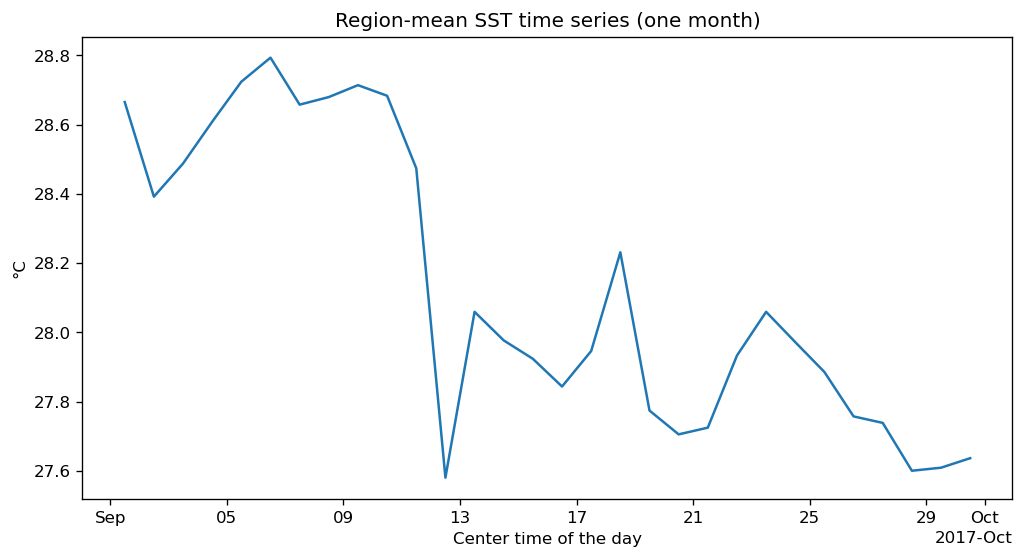

Warmest day: 2017-09-06 28.793123245239258
Coolest day: 2017-09-12 27.580623626708984


C:\Users\macdonaldc\AppData\Local\Temp\ipykernel_14016\4235597154.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
C:\Users\macdonaldc\AppData\Local\Temp\ipykernel_14016\4235597154.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


In [ ]:
ts = dss[var].mean(dim=['lat','lon'])

ts_mean = ts.mean().compute()
ts_std  = ts.std().compute()
print('Month mean SST (°C):', float(ts_mean.values))
print('Month std SST (°C):', float(ts_std.values))

ts.load().plot()
plt.title('Region-mean SST time series (one month)')
plt.ylabel('°C')
plt.show()

imax = int(ts.argmax('time'))
imin = int(ts.argmin('time'))
print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


Max anomaly (°C): 0.6652288436889648
Min anomaly (°C): -0.547270655632019


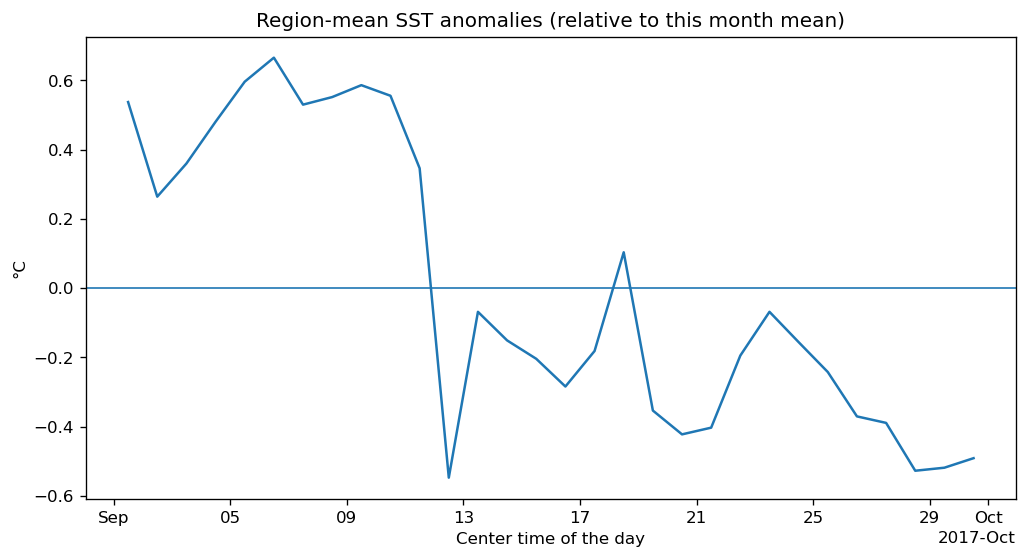

In [20]:
month_mean = dss[var].mean('time')
anom = dss[var] - month_mean

ts_anom = anom.mean(dim=['lat','lon'])
print('Max anomaly (°C):', float(ts_anom.max().compute().values))
print('Min anomaly (°C):', float(ts_anom.min().compute().values))

ts_anom.load().plot()
plt.title('Region-mean SST anomalies (relative to this month mean)')
plt.axhline(0, lw=1)
plt.ylabel('°C')
plt.show()


## 5) Regional maps: month-mean and variability

Make maps of month-mean SST and within-month variability (std and range).

**🧩 Questions**
1. What patterns do you notice?  
A: I may have picked too small of a boundary area to properly pull out interesting trends, but it appears that the warmest area is  
to the SW, while the coldest areas are to the NW and SE. There is less variance in the north than the south.
2. Where is variability strongest?  
A: Variability is strongest in the SE of the boundary area, where both STD and range are greatest.


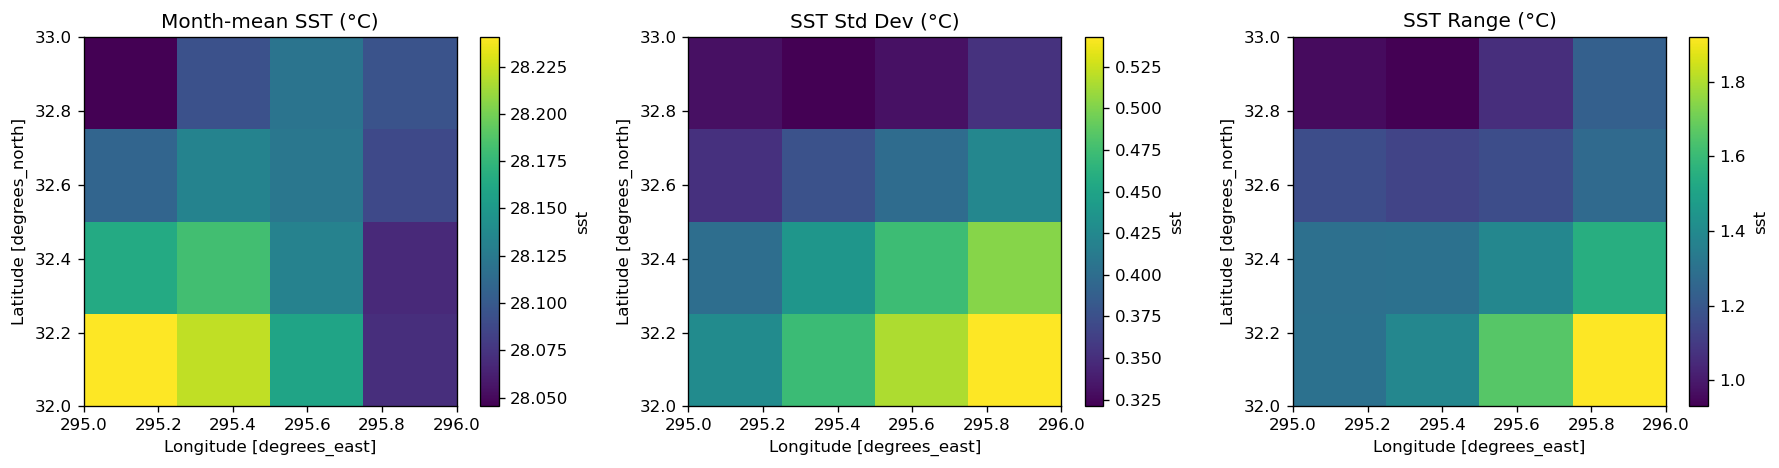

In [21]:
mean_sst = dss[var].mean('time')
std_sst  = dss[var].std('time')
range_sst = dss[var].max('time') - dss[var].min('time')

fig = plt.figure(figsize=(15,4))
ax = plt.subplot(1,3,1); mean_sst.plot(ax=ax); ax.set_title('Month-mean SST (°C)')
ax = plt.subplot(1,3,2); std_sst.plot(ax=ax); ax.set_title('SST Std Dev (°C)')
ax = plt.subplot(1,3,3); range_sst.plot(ax=ax); ax.set_title('SST Range (°C)')
plt.tight_layout(); plt.show()


## 6) Export a small subset for sharing (Check In Problem for Module 2)

Write a NetCDF with your regional mean time series and month-mean/variability maps.  Upload with your committed repository.

A: Done! Saved as bermuda_sst_regional_maps_201709.nc

In [23]:
# I'm interpreting this to mean the maps are included as vars in the netcdf, not as separate pngs
bermuda_ds = xr.Dataset({
    # Regional mean time series
    'regional_mean_sst': ts,
    # month/mean vars for maps
    'month_mean_sst': mean_sst,
    'month_std_sst': std_sst,
    'month_range_sst': range_sst
})
bermuda_ds.to_netcdf("bermuda_sst_regional_maps_201709.nc")